<h1> Matched_filter</h1>


In [10]:
from numba import njit, prange

In [11]:
######## 2D Imaging in Cartesian #############
@njit(fastmath=True, parallel=True)
def matched_filter_2d(raw_data_2d, x_grid, z_grid, y_grid, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx, lm, ts, slope, c, MF_output):
    """
    Performs 2D matched filter on the raw data.
    - raw_data_2d: raw data  
    - num_x_cells: x axis values (azimuth)
    - num_z_cells: z axis values (elevation)
    - num_y_cells: y axis values (range)
    - x_radar_tx: transmitter positions (x) 
    - x_radar_rx: receiver positions (x)
    - z_radar_tx: transmitter positions (z)
    - z_radar_rx: receiver positions (z)
    
    Returns:
    - MF_output: matched filter output (size: num_x_cells x num_y_cells  x num_z_cells aka azimuth, depth, elevation)
    """

    for x_i in prange(len(x_grid)):  # Parallel execution on the outer loop
        x = x_grid[x_i]
        for z_i in prange(len(z_grid)):  # Parallel execution
            z = z_grid[z_i]
            for y_i in range(len(y_grid)):  # Keep inner loops serial for cache efficiency
                y = y_grid[y_i]
                for m in range(len(x_radar_tx)):
                    for k_i in range(len(z_radar_tx)):
                        for t_i in range(len(ts)):
                            tt = ts[t_i]

                            # Compute distances
                            distances_rx = np.sqrt((x - x_radar_rx[m])**2 + y**2 + (z - z_radar_rx[k_i])**2)
                            distances_tx = np.sqrt((x - x_radar_tx[m])**2 + y**2 + (z - z_radar_tx[k_i])**2)
                            distances = distances_rx + distances_tx

                            # Compute phase
                            phase_shifts = np.exp(-1j * 2 * np.pi * (slope*tt / c + 1 / lm) * distances)

                            # Apply matched filter
                            MF_output[x_i, z_i, y_i] += np.sum(raw_data_2d[m, k_i, t_i] * phase_shifts)

    return MF_output

In [1]:
######## 2D Imaging in Cartesian #############
def matched_filter_2d(raw_data_2d, num_x_cells, num_z_cells, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx, num_y_cells):
    """
    Computes the 2D matched filter result for raw data, this is done along the X, Y dimensions (results in a birds eye view image).

    Paramters:
    - raw_data_2d: raw ADC data (size: num Tx * num Rx * horizontal steps * vertical steps, num ADC samples)
    - num_x_cells: discrete locations in X (horizontal) that you want to compute the power of
    - num_z_cells: discrete locations in Z (vertical) that you want to compute the power of
    - x_radar_tx: horizontal positions of the transmitters
    - x_radar_rx: horizontal positions of the receivers
    - z_radar_tx: vertical positions of the transmitters
    - z_radar_rx: vertical positions of the receivers
    - cell_y: depth slice we want to calculate

    Returns:
    - MF_output: matched filter output
    """
    c = 2.9979
    fc_start =  773.704
    chirpSlope = 70.295e12
    adcSampleRate = 10e6
    As_sci = (chirpSlope/1e8)

    # to speed up processing just look at this subset of samples
    adc_sampless = np.arange(radar_params['adc_samples'])
    adc_sampless = np.arange(0,30)
    X_ = raw_data_2d[:,adc_sampless]
    adc_samples_mf = X_.shape[1]

    MF_output = np.zeros((len(num_x_cells),len(num_z_cells),len(num_y_cells)),dtype=complex)
    index = 0
    for i,cell_x in enumerate(num_x_cells):
        for j,cell_z in enumerate(num_z_cells):
            for k,cell_y in enumerate(num_y_cells):
                start_time = time.time()

                # round trip distance of signal to (cell_x, cell_y, cell_z)
                cell_dist = np.sqrt((x_radar_tx - cell_x)**2 + (cell_y)**2 + (z_radar_tx - cell_z)**2) + np.sqrt((cell_x - x_radar_rx)**2 + (cell_y)**2 + (z_radar_rx - cell_z)**2) # size is (num_z_stp,1)

                cell_dist = np.reshape(cell_dist,(-1,1)) + 0.15 # account for range bias
                temp_tau = (cell_dist)/c

                temp_sig_phase = 2.0*np.pi*fc_start*temp_tau
                total_phase = np.repeat(temp_sig_phase,adc_samples_mf,axis=1) + 2.0 * np.pi * As_sci * (adc_sampless.T / adcSampleRate) * temp_tau
                temp_real = np.cos(total_phase)
                temp_imag = -np.sin(total_phase)
                MF_output[i,j,k] = MF_output[i,j,k] + np.sum((X_ *  (temp_real + temp_imag*1j)),axis=(0,1))

                print("Processed cell (%.2f,%.2f,%.2f), which is (%d/ %d) and took %.2f sec)    " % (cell_x,cell_y,cell_z,index,len(num_x_cells)*len(num_z_cells)*len(num_y_cells),abs(start_time - time.time())), end='\r')
                index += 1
    return MF_output

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.io as sio
import time
import open3d as o3d
import helpers 
import utils
import os

Load data.

In [38]:
# Define the path to the data
data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/Group_2/COM-304-Radars/homework/data/data_003_.mat'
save_data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/Group_2/COM-304-Radars/homework/data/project/matched_filter_2d_output/data_003_3'

# loading data that is given
"""
    raw_data: is the raw radar data (after mixing) of size (num_x_stp x num_rx, num_z_stp, adc_samples)
    radar_params: is a dictionary with radar and position parameters: 'sample_rate', 'num_samples', 'slope', 'lm'(lambda), 'num_x_stp', 'num_z_stp', 'num_tx', 'num_rx', 'adc_samples' 
"""
radar_params, raw_data = utils.load_raw_data(data_path)
lm = radar_params["lm"]
slope = radar_params["slope"]

Defining antenna positions.

In [5]:
x_ant_pos, z_ant_pos, x_ant = utils.get_ant_pos_2d(radar_params['num_x_stp'], radar_params['num_z_stp'], radar_params['num_rx']) # this returns x position of rx, z positions of rx and tx, and x position of tx

Process raw data for MF algorthim (use all samples now).

In [6]:
X = raw_data.reshape((radar_params['num_x_stp'], radar_params['num_z_stp'], radar_params['adc_samples']))

Front view of the scene.

In [20]:
# Define the grid
res = 0.03
x_max = 0.5
x_min = -0.5
x_grid = np.arange(x_min, x_max, res)

z_max = 0.5
z_min = -0.5
z_grid = np.arange(z_min, z_max, res)

y_max = 4.31
y_min = 4.3
y_grid = np.arange(y_min, y_max, 0.01)

# Define the time samples
t = np.arange(100, 120)/radar_params["sample_rate"]

x_radar_tx = np.repeat(x_ant, 4)
x_radar_rx = x_ant_pos
z_radar_tx = z_ant_pos.reshape(369)
z_radar_rx = z_ant_pos.reshape(369)

# Initialize output
MF_output = np.zeros((len(x_grid), len(z_grid), len(y_grid)), dtype=np.complex64)

# Run matched filter algorithm
MF_output = matched_filter_2d(X, x_grid, z_grid, y_grid, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx, lm, t, slope, 3e8, MF_output)

In [21]:
# Ensure the directory exists
os.makedirs(save_data_path + "/Front_view", exist_ok=True)

# Save the output
np.save(save_data_path + "/Front_view" + "/data_output.npy", MF_output)

# Save the grid
np.savez(save_data_path + "/Front_view" + "/data_grid.npz", x_max= x_max, x_min= x_min, z_max= z_max, z_min= z_min, y_max= y_max, y_min= y_min, res= res)

In [22]:
# Load the output
MF_output_003 = np.load(save_data_path + "/Front_view" + "/data_output" + ".npy")

# Load the grid
grid = np.load(save_data_path + "/Front_view" + "/data_grid" + ".npz")
x_max = grid['x_max']
x_min = grid['x_min']
z_max = grid['z_max']
z_min = grid['z_min']
y_max = grid['y_max']
y_min = grid['y_min']
res = grid['res']


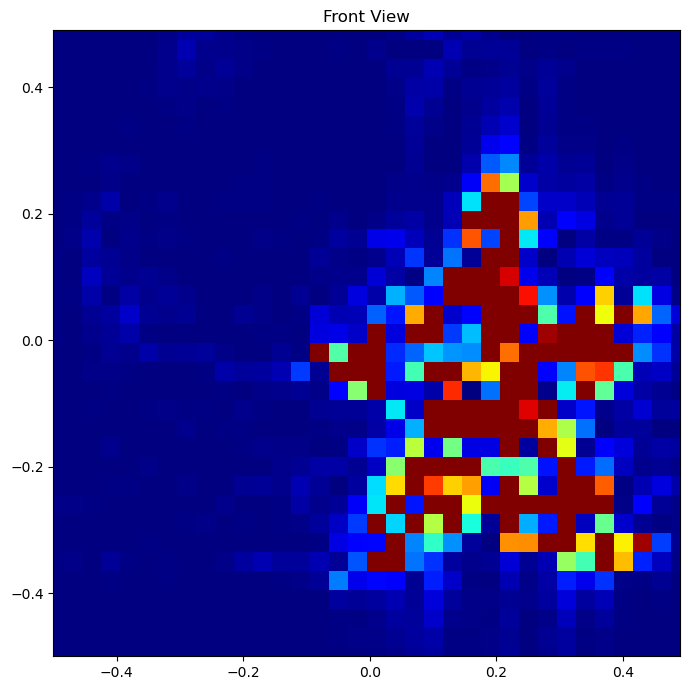

In [23]:
# Define the grid
x_grid = np.arange(x_min, x_max, res)
z_grid = np.arange(z_min, z_max, res)
y_grid = np.arange(y_min, y_max, res)

# Plot the Front view
fig = plt.figure(figsize=(7, 7))
MF = MF_output_003
to_plot = np.sum(abs(MF),axis=-1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))
to_plot = to_plot**2
ax0 = fig.add_subplot(111)
utils.plot_2d_heatmap(ax0, to_plot, x_grid, z_grid, vmin=0, vmax=0.1)
ax0.title.set_text('Front View')

plt.tight_layout()
plt.show()

Top view of the scene.

In [62]:
# Define the grid
res = 0.01
x_max = 0.6
x_min = -0.2
x_grid = np.arange(x_min, x_max, res)

z_max = 0.01
z_min = 0.0
z_grid = np.arange(z_min, z_max, res)

y_max = 5.2
y_min = 3.5
y_grid = np.arange(y_min, y_max, res)

# Define the time samples
t = np.arange(100, 140)/radar_params["sample_rate"]

x_radar_tx = np.repeat(x_ant, 4)
x_radar_rx = x_ant_pos
z_radar_tx = z_ant_pos.reshape(369)
z_radar_rx = z_ant_pos.reshape(369)

# Initialize output
MF_output = np.zeros((len(x_grid), len(z_grid), len(y_grid)), dtype=np.complex64)

# Run matched filter algorithm
MF_output = matched_filter_2d(X, x_grid, z_grid, y_grid, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx, lm, t, slope, 3e8, MF_output)

In [63]:
# Ensure the directory exists
os.makedirs(save_data_path + "/Top_view", exist_ok=True)

# Save the output
np.save(save_data_path + "/Top_view" + "/data_output.npy", MF_output)

# Save the grid
np.savez(save_data_path + "/Top_view" + "/data_grid.npz", x_max= x_max, x_min= x_min, z_max= z_max, z_min= z_min, y_max= y_max, y_min= y_min, res= res)

In [64]:
# Load the output
MF_output_003 = np.load(save_data_path + "/Top_view" + "/data_output" + ".npy")

# Load the grid
grid = np.load(save_data_path + "/Top_view" + "/data_grid" + ".npz")
x_max = grid['x_max']
x_min = grid['x_min']
z_max = grid['z_max']
z_min = grid['z_min']
y_max = grid['y_max']
y_min = grid['y_min']
res = grid['res']
print(res)

0.01


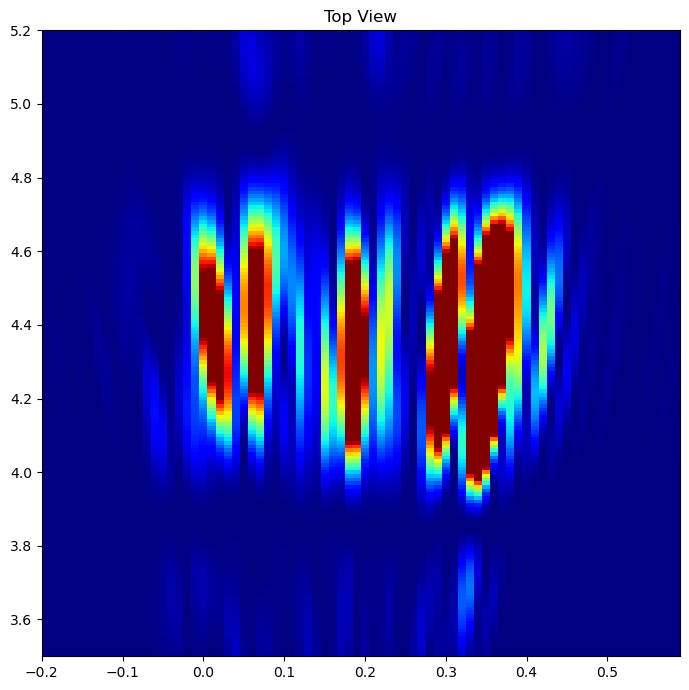

In [70]:
# Define the grid
x_grid = np.arange(x_min, x_max, res)
z_grid = np.arange(z_min, z_max, res)
y_grid = np.arange(y_min, y_max, res)

# Plot the Front view
fig = plt.figure(figsize=(7, 7))
MF = MF_output_003
to_plot = np.sum(abs(MF),axis=1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))
to_plot = to_plot**2
ax0 = fig.add_subplot(111)
utils.plot_2d_heatmap(ax0, to_plot, x_grid, y_grid, vmin=0, vmax=0.1)
ax0.title.set_text('Top View')

plt.tight_layout()
plt.show()

3d view of the scene.

In [ ]:
# Define the grid
res = 0.01
x_max = 0.5
x_min = -0.5
x_grid = np.arange(x_min, x_max, res)

z_max = 0.5
z_min = -0.5
z_grid = np.arange(z_min, z_max, res)

y_max = 0.31
y_min = 0.3
y_grid = np.arange(y_min, y_max, 0.01)

# Define the time samples
t = np.arange(100, 120)/radar_params["sample_rate"]

x_radar_tx = np.repeat(x_ant, 4)
x_radar_rx = x_ant_pos
z_radar_tx = z_ant_pos.reshape(498)
z_radar_rx = z_ant_pos.reshape(498)

# Initialize output
MF_output = np.zeros((len(x_grid), len(z_grid), len(y_grid)), dtype=np.complex64)

# Run matched filter algorithm
MF_output = matched_filter_2d(X, x_grid, z_grid, y_grid, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx, lm, t, slope, 3e8, MF_output)

# Save the output
np.save(data_path + "/3d_view" + "data_ouput", MF_output)

# Save the grid
np.savez(save_data_path + "/3d_view" + "/data_grid", x_max= x_max, x_min= x_min, z_max= z_max, z_min= z_min, y_max= y_max, y_min= y_min, res= res)

In [ ]:
# Load the output
MF_output_003 = np.load(save_data_path + "/3d_view" + "/data_output" + ".npy")

# Load the grid
grid = np.load(save_data_path + "/3d_view" + "/data_grid" + ".npz")
x_max = grid['x_max']
x_min = grid['x_min']
z_max = grid['z_max']
z_min = grid['z_min']
y_max = grid['y_max']
y_min = grid['y_min']
res = grid['res']

In [ ]:
# Define the grid
x_grid = np.arange(x_min, x_max, res)
z_grid = np.arange(z_min, z_max, res)
y_grid = np.arange(y_min, y_max, res)

# Plot the Front view
fig = plt.figure(figsize=(7, 7))
MF = MF_output_003
to_plot = np.sum(abs(MF),axis=-1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))
to_plot = to_plot**2
ax0 = fig.add_subplot(111)
utils.plot_2d_heatmap(ax0, to_plot, x_grid, z_grid, vmin=0, vmax=0.1)
ax0.title.set_text('3d View')

plt.tight_layout()
plt.show()